In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import xgboost as xgb
from sklearn.metrics import confusion_matrix
from math import pi
import plotly.graph_objects as go
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(os.path.join("..", "data", "processed", "training_data_with_clusters.csv"))

df.head()

,driver_id,signup_date,avg_rating,current_tier,Churned,avg_earnings_per_hour_online,trip_utilization_rate,surge_reliance_score,is_premium_capable,premium_trip_ratio,peak_hour_driver_score,session_regularity,quest_completion_rate,incentive_reliance_pct,pro_tier_rank,cancellation_rate,acceptance_rate,session_count,cluster_label
0,5729981b-bf65-48ac-a418-95693a8d26ef,2025-07-16 08:43:42.076226-04:00,4.84,Blue,0,12.716965,0.429709,0.084820,0,0.000000,0.309091,89.034310,0.000000,0.000000,1,0.115152,0.666667,30,0
1,caf9988b-9ff9-4dcc-b9a5-4d6953ac8a0b,2025-11-04 02:36:10.076226-05:00,4.80,Platinum,0,17.065534,0.525368,0.113678,0,0.000000,0.298188,3.705339,0.875000,0.115524,3,0.093171,0.851168,132,1
2,5d9761b2-ee05-4923-98ca-1f16a4a6df73,2025-06-27 03:06:08.076226-04:00,4.91,Diamond,0,31.851693,0.419952,0.176612,1,0.806924,0.307590,30.094497,0.166667,0.005854,4,0.021991,0.497644,114,2
3,0a298bab-317f-49f7-a021-432c6cf80366,2025-10-18 22:08:13.076226-04:00,4.94,Platinum,0,31.627454,0.400830,0.225439,1,0.798283,0.271817,9.303206,0.166667,0.004039,3,0.014360,0.495407,108,2
4,5843b2fc-ffa0-4cd2-a0bc-c950eecab4f0,2025-08-14 01:17:21.076226-04:00,4.72,Blue,1,12.421348,0.400394,0.144122,0,0.000000,0.276596,57.364287,0.000000,0.000000,1,0.145833,0.584323,48,0


In [3]:
print(f"Dimensions: {df.shape}")
print(f"Cluster Sizes:\n{df['cluster_label'].value_counts().sort_index()}")

Dimensions: (581, 19)
Cluster Sizes:
cluster_label
0    194
1    184
2     96
3    107
Name: count, dtype: int64


In [4]:
cluster_features = [
    'avg_earnings_per_hour_online',
    'trip_utilization_rate',
    'surge_reliance_score',
    'premium_trip_ratio',
    'quest_completion_rate',
    'cancellation_rate'
]

In [5]:
cluster_means = df.groupby('cluster_label')[cluster_features].mean()

In [6]:
scaler_min = df[cluster_features].min()
scaler_max = df[cluster_features].max()
normalized_means = (cluster_means - scaler_min) / (scaler_max - scaler_min)

In [7]:
df_melted = normalized_means.reset_index().melt(id_vars='cluster_label')
df_melted.columns = ['Cluster', 'Attribute', 'Normalized Value']

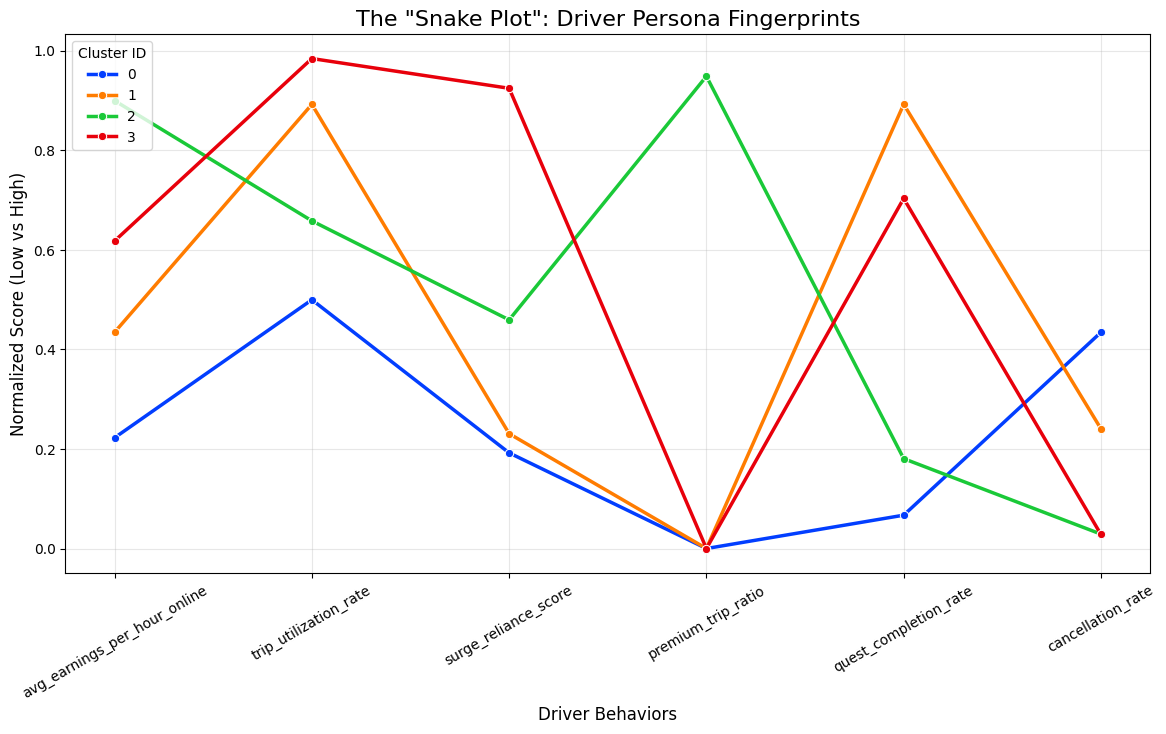

In [8]:
# --- PLOTTING ---
plt.figure(figsize=(14, 7))

# Draw the lines
sns.lineplot(
    data=df_melted, 
    x='Attribute', 
    y='Normalized Value', 
    hue='Cluster', 
    palette='bright', 
    marker='o', 
    linewidth=2.5
)

plt.title('The "Snake Plot": Driver Persona Fingerprints', fontsize=16)
plt.ylabel('Normalized Score (Low vs High)', fontsize=12)
plt.xlabel('Driver Behaviors', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Cluster ID', loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

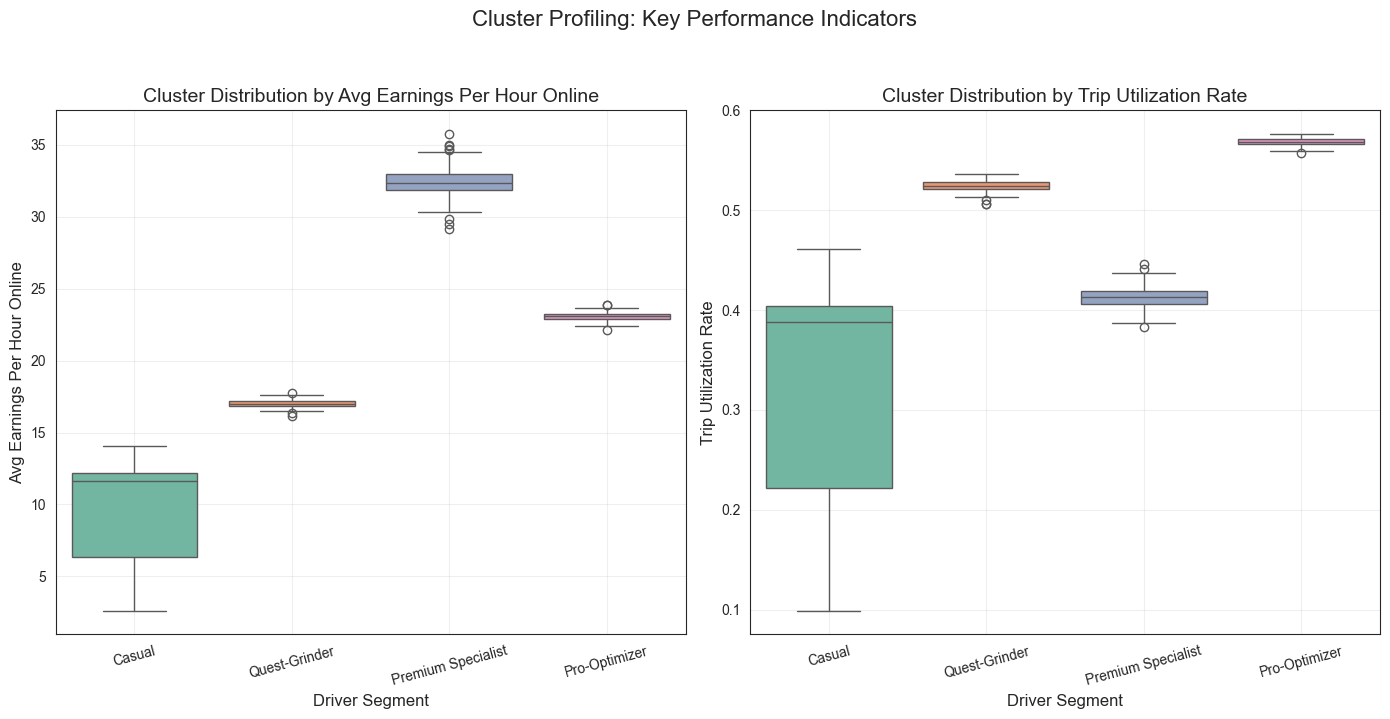

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your cluster mapping
cluster_dict = {
    0: "Casual",
    1: "Quest-Grinder",
    2: "Premium Specialist",
    3: "Pro-Optimizer"
}

# 2. Map the numbers to names in a new column
df['cluster_name'] = df['cluster_label'].map(cluster_dict)

features_to_check = ['avg_earnings_per_hour_online', 'trip_utilization_rate']

# Increased figure size for better vertical space
plt.figure(figsize=(14, 7))

for i, col in enumerate(features_to_check):
    # Used (1, 2) layout for two plots
    plt.subplot(1, 2, i+1)
    
    sns.boxplot(
        x='cluster_name',      # Updated to use the new named column
        y=col,
        data=df,
        palette='Set2',
        # If your previous order was a list of unique numbers, map them here. 
        # Otherwise, you can just list the names in your preferred order:
        order=["Casual", "Quest-Grinder", "Premium Specialist", "Pro-Optimizer"] 
    )
    
    plt.title(f'Cluster Distribution by {col.replace("_", " ").title()}', fontsize=14)
    plt.xlabel('Driver Segment', fontsize=12) # Updated to make more sense with names
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
    
    # 3. Added a slight rotation so the new longer names don't overlap
    plt.xticks(rotation=15) 
    plt.grid(True, alpha=0.3)

plt.suptitle('Cluster Profiling: Key Performance Indicators', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [10]:
os.path.join("..", "data", "processed", "training_data_with_clusters.csv")

'..\\data\\processed\\training_data_with_clusters.csv'

Churn Model Loaded.


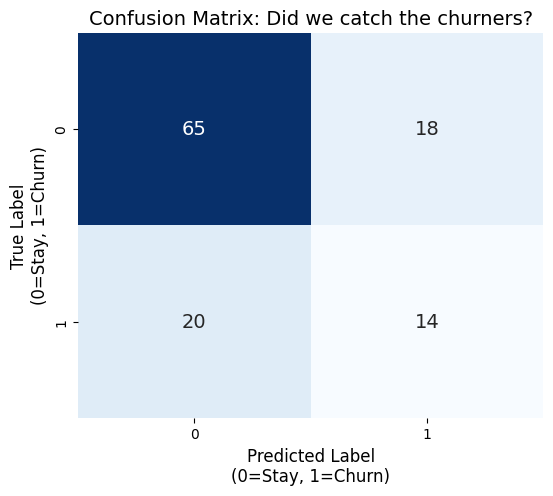

In [11]:
# 1. Load the Saved Churn Model
# Note: XGBoost models save as JSON, but we need to reconstruct the object
churn_model = xgb.XGBClassifier()
churn_model.load_model(os.path.join("..","models", "churn_model_optimized.json"))

print("Churn Model Loaded.")

# 2. Prepare the Test Data (Re-creating the split exactly as we did in training)
# We need to do this to get the X_test and y_test data again
from sklearn.model_selection import train_test_split

# Prepare Feature Matrix X and Target y
# We must cast cluster_label to category again
df['cluster_label'] = df['cluster_label'].astype('category')

features_for_model = [
    'avg_earnings_per_hour_online', 'trip_utilization_rate', 'surge_reliance_score',
    'premium_trip_ratio', 'quest_completion_rate', 'cancellation_rate',
    'acceptance_rate', 'pro_tier_rank', 'cluster_label'
]

X = df[features_for_model]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Predict
y_pred = churn_model.predict(X_test)

# 4. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 14})
plt.xlabel('Predicted Label\n(0=Stay, 1=Churn)', fontsize=12)
plt.ylabel('True Label\n(0=Stay, 1=Churn)', fontsize=12)
plt.title('Confusion Matrix: Did we catch the churners?', fontsize=14)
plt.show()

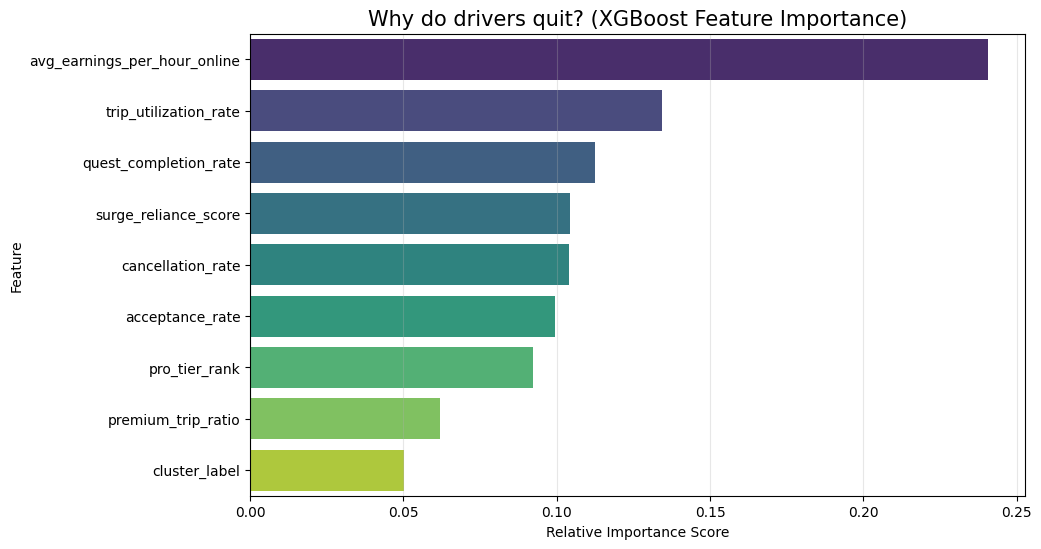

In [12]:
# Get feature importance from the model
importance = churn_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Why do drivers quit? (XGBoost Feature Importance)', fontsize=15)
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [13]:
# --- Data Preparation ---
cluster_names = {
    0: "Casual",
    1: "Quest-Grinder",
    2: "Premium Specialist",
    3: "Pro-Optimizer"
}

df['Persona'] = df['cluster_label'].map(cluster_names)

# Calculate Churn Rate
churn_rate = df.groupby('Persona')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False)

# --- Plotly Visualization ---

# Create the Bar Chart
fig = px.bar(
    churn_rate,
    x='Persona',
    y='Churned',
    title='Risk Analysis: Which Personas are we losing?',
    text='Churned',  # This adds the value labels automatically
    color='Churned', # Optional: Maps color intensity to the churn rate
    color_continuous_scale='Reds', # Matches your 'Reds_r' palette
    range_y=[0, 1]   # Sets the Y-axis limit from 0 to 1
)

# Update Layout for polish
fig.update_traces(
    texttemplate='%{text:.1%}', # Formats the label as a percentage (e.g., 25.4%)
    textposition='outside'      # Places the label on top of the bar
)

fig.update_layout(
    yaxis_title='Churn Rate (0.0 to 1.0)',
    xaxis_title='Persona',
    title_font_size=20,
    yaxis=dict(showgrid=True, gridcolor='rgba(0,0,0,0.1)'), # Custom grid styling
    coloraxis_showscale=False # Hides the color legend sidebar if you don't need it
)

fig.show()

In [14]:
# 2. DATA PREPARATION
# ---------------------------------------------------------
# Select Operational Metrics
metrics = [
    'acceptance_rate',
    'trip_utilization_rate', 
    'surge_reliance_score',
    'quest_completion_rate',
    'cancellation_rate',
    'avg_earnings_per_hour_online'
]

# Friendly Label Names for the Chart
metric_labels = [
    'Acceptance \nRate', 'Trip Utilization', 'Surge Reliance', 
    'Quest Completion', 'Cancellation Rate', 'Avg Earnings/Hr'
]

# Normalize Data (Min-Max Scaling to 0-1 range)
cluster_means = df.groupby('cluster_label')[metrics].mean()
min_vals = df[metrics].min()
max_vals = df[metrics].max()
normalized_means = (cluster_means - min_vals) / (max_vals - min_vals)

# Define Persona Names & Refined Colors (Better Contrast)
persona_names = {
    0: "Casual Driver",
    1: "Quest Grinder",
    2: "Premium Specialist",
    3: "Pro-Optimizer"
}

# Updated Palette: Using hex codes for high distinction
colors = {
    0: '#E74C3C', # Red (Casual/Risk - High Visibility)
    1: '#3498DB', # Blue (Pro)
    2: '#9B59B6', # Purple (Premium)
    3: '#2ECC71'  # Green (Quest)
}

# 3. BUILD THE PLOTLY CHART
# ---------------------------------------------------------
fig = go.Figure()

# CONTROL DRAW ORDER: Plot Cluster 0 LAST so it sits on top
# Order: [1, 2, 3, 0]
plot_order = [1, 2, 3, 0]

for i in plot_order:
    if i not in normalized_means.index: continue

    # Get values and close the loop for radar chart
    r_values = normalized_means.loc[i].values.tolist()
    r_values += r_values[:1]
    
    theta_values = metric_labels
    theta_values += theta_values[:1]
    
    # Styling logic: Make Cluster 0 thicker and more opaque
    line_w = 4 if i == 0 else 2
    fill_op = 0.7 if i == 0 else 0.4
    
    fig.add_trace(go.Scatterpolar(
        r=r_values,
        theta=theta_values,
        fill='toself',
        name=persona_names[i],
        mode='lines+markers', 
        marker=dict(size=5),
        line=dict(color=colors[i], width=line_w),
        opacity=1.0 if i == 0 else 0.7, # Make background layers slightly transparent
        fillcolor=colors[i], 
        # Note: fill opacity is handled by plotly's trace opacity usually, 
        # or use rgba colors if needed.
    ))

# 4. FINALIZE DESIGN
# ---------------------------------------------------------
fig.update_layout(
    title={
        'text': "<b>Driver Persona Fingerprints</b><br><sub>(Operational Metrics Comparison)</sub>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1], # FORCES the 0 to 100% scale
            showticklabels=False, # Clean look
            gridcolor="#E0E0E0", # Subtle grid
            linecolor="black", 
            linewidth=1
        ),
        angularaxis=dict(
            tickfont=dict(size=12, color="#333333", family="Arial, sans-serif"),
            linecolor="black", 
            linewidth=2
        ),
        bgcolor="white"
    ),
    legend=dict(
        title="Driver Segments",
        orientation="v",
        y=0.5,
        x=1.05
    ),
    width=800,
    height=600
)

fig.show()

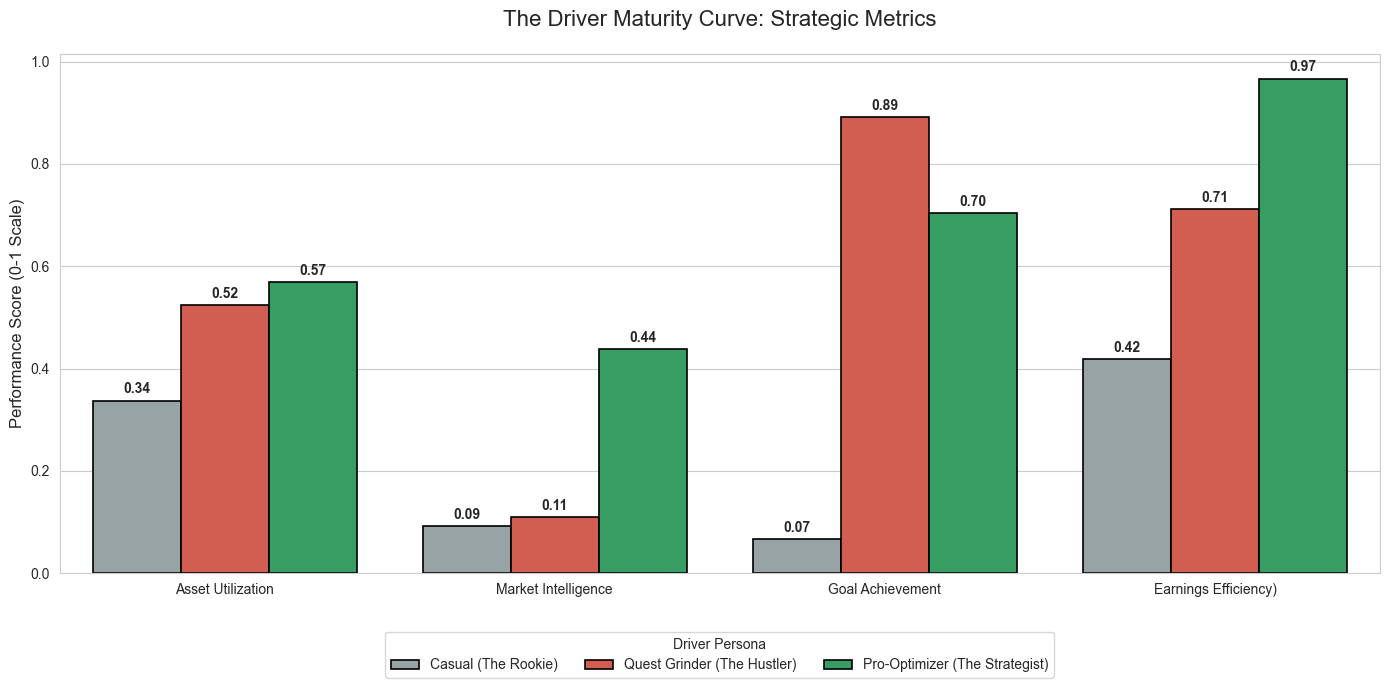

In [15]:
# 1. Prepare the Data
# We compare Casual (0), Quest Grinder (1), and Pro-Optimizer (3)
target_clusters = [0, 1, 3]
df_gap = df[df['cluster_label'].isin(target_clusters)].copy()

# Map labels to names for readability
cluster_names = {
    0: 'Casual (The Rookie)',
    3: 'Pro-Optimizer (The Strategist)',
    1: 'Quest Grinder (The Hustler)'
}
df_gap['Persona'] = df_gap['cluster_label'].map(cluster_names)

# 2. Select Strategic Metrics
# Added 'surge_reliance_score' back
metrics_to_compare = [
    'trip_utilization_rate',       # Effort: Are they staying busy?
    'surge_reliance_score',        # Skill: Are they driving at the right time?
    'quest_completion_rate',       # Drive: Are they hitting their targets?
    'avg_earnings_per_hour_online' # Outcome: Are they making money?
]

# Normalize earnings for the chart (0-1 scale)
df_gap['normalized_earnings'] = df_gap['avg_earnings_per_hour_online'] / df_gap['avg_earnings_per_hour_online'].max()

# Update list to use normalized version
plot_metrics = ['trip_utilization_rate', 'surge_reliance_score', 'quest_completion_rate', 'normalized_earnings']

# Melt for plotting
df_melted = df_gap.melt(
    id_vars=['Persona'], 
    value_vars=plot_metrics, 
    var_name='Metric', 
    value_name='Score'
)

# Friendly Labels - Including Market Intelligence
metric_labels = {
    'trip_utilization_rate': 'Asset Utilization',
    'surge_reliance_score': 'Market Intelligence',
    'quest_completion_rate': 'Goal Achievement',
    'normalized_earnings': 'Earnings Efficiency)'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# 3. Create the Chart
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Palette
palette = {
    'Casual (The Rookie)': '#95A5A6', 
    'Quest Grinder (The Hustler)': '#E74C3C', 
    'Pro-Optimizer (The Strategist)': '#27AE60'
}

ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Persona',
    palette=palette,
    edgecolor='black',
    linewidth=1.2,
    errorbar=None
)

# Add value labels
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10, weight='bold')

plt.title('The Driver Maturity Curve: Strategic Metrics', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('Performance Score (0-1 Scale)', fontsize=12)
plt.legend(title='Driver Persona', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()

plt.show()

In [16]:


# Assuming the files are in the current directory
RAW_DATA_PATH = os.path.join("..", "data", "raw")

profile_data = df.copy()
activity_logs = pd.read_csv(os.path.join(RAW_DATA_PATH, 'activity_logs.csv'))
trip_logs = pd.read_csv(os.path.join(RAW_DATA_PATH, 'trip_logs.csv'))
incentive_logs = pd.read_csv(os.path.join(RAW_DATA_PATH, 'incentive_logs.csv'))
interaction_logs = pd.read_csv(os.path.join(RAW_DATA_PATH, 'interaction_logs.csv'))

<Figure size 1000x700 with 0 Axes>

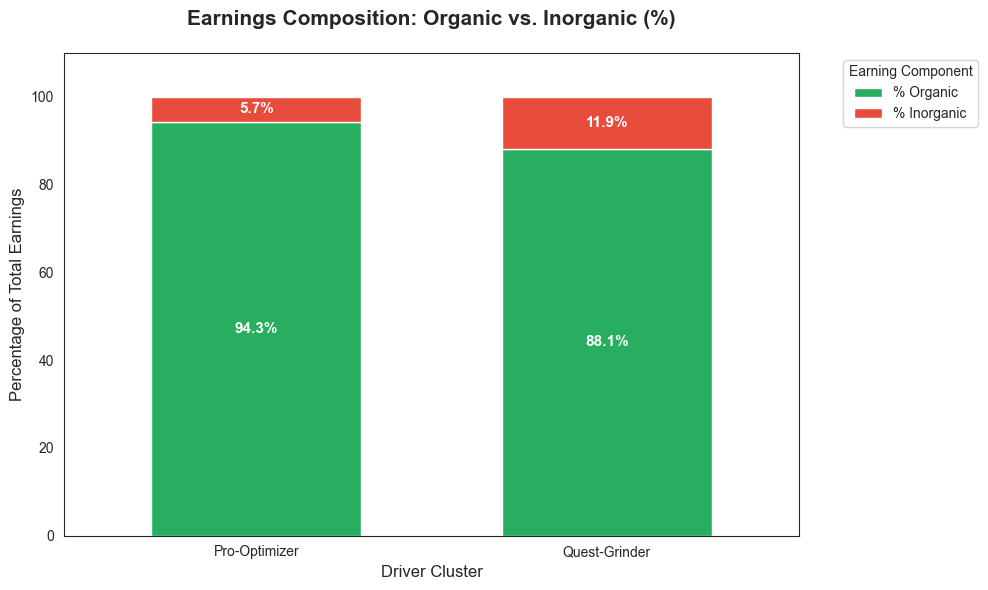

In [17]:
# 2. Calculate Organic Earnings (Fare + Tip)
# Trip logs contain 'fare' and 'tip' columns
trip_logs['organic_earnings'] = trip_logs['fare'] + trip_logs['tip']
organic_df = trip_logs.groupby('driver_id')['organic_earnings'].sum().reset_index()

# 3. Calculate Inorganic Earnings (Completed Incentives)
# Filter for 'completed' status in incentive_logs
inorganic_df = incentive_logs[incentive_logs['status'] == 'completed'].groupby('driver_id')['bonus_amount'].sum().reset_index()
inorganic_df.rename(columns={'bonus_amount': 'inorganic_earnings'}, inplace=True)

# 4. Merge and Calculate Percentages
driver_metrics = profile_data[['driver_id', 'cluster_label']].merge(organic_df, on='driver_id', how='left')
driver_metrics = driver_metrics.merge(inorganic_df, on='driver_id', how='left').fillna(0)

# Calculate Total and Percentages
driver_metrics['total_earnings'] = driver_metrics['organic_earnings'] + driver_metrics['inorganic_earnings']
driver_metrics['% Organic'] = (driver_metrics['organic_earnings'] / driver_metrics['total_earnings']) * 100
driver_metrics['% Inorganic'] = (driver_metrics['inorganic_earnings'] / driver_metrics['total_earnings']) * 100

# 5. Filter and Map Clusters
cluster_map = {3: "Pro-Optimizer", 1: "Quest-Grinder"} #
filtered_df = driver_metrics[driver_metrics['cluster_label'].isin([1, 3])].copy()
filtered_df['cluster_name'] = filtered_df['cluster_label'].map(cluster_map)

# Aggregate the mean percentages for the visualization
plot_data = filtered_df.groupby('cluster_name')[['% Organic', '% Inorganic']].mean()

# 6. Visualization: Stacked Percentage Bar Chart
plt.figure(figsize=(10, 7))
sns.set_style("white")

# Plotting
ax = plot_data.plot(kind='bar', stacked=True, color=['#27ae60', '#e74c3c'], figsize=(10, 6), width=0.6)

# Formatting
plt.title('Earnings Composition: Organic vs. Inorganic (%)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Percentage of Total Earnings', fontsize=12)
plt.xlabel('Driver Cluster', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 110) # Room for legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Earning Component')

# Add percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only label segments large enough to read
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()